In [ ]:
from sklearn.datasets import load_wine
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np 
from sklearn.metrics import accuracy_score
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [ ]:
wine = load_wine()
X = wine.data
y = wine.target

wine_df = pd.DataFrame(data=wine.data, columns=wine.feature_names)
print(wine_df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  
0                  

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2, 
    random_state=42,
    stratify=y
)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.fit_transform(X_test)

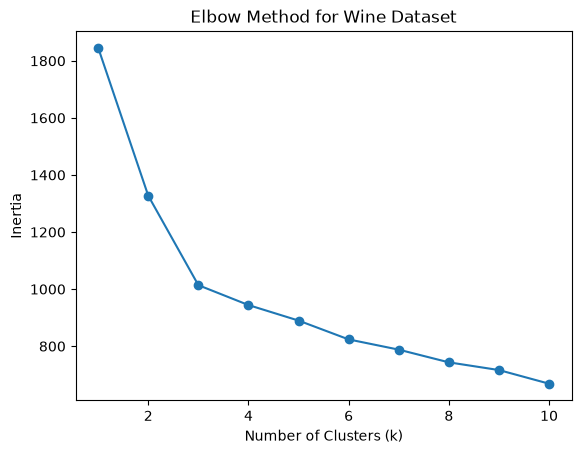

In [ ]:
inertias = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)

plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Wine Dataset")

plt.show()

In [14]:
optimal_k = 3 # Identified using elbow method

In [15]:
kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=20
)

train_clusters = kmeans.fit_predict(
    X_train_scaled
)

In [16]:
print(kmeans.cluster_centers_)

[[ 0.86328181 -0.26946803  0.33591406 -0.64662019  0.57440439  0.88970666
   0.9818559  -0.55094319  0.53374286  0.1661911   0.46805073  0.76666326
   1.15665656]
 [ 0.14637886  0.86434879  0.20436112  0.48622742 -0.09010021 -0.9520786
  -1.22490499  0.75439573 -0.80713736  0.94747415 -1.15537009 -1.28528592
  -0.43121414]
 [-0.92889119 -0.42758398 -0.47766529  0.22594356 -0.47022512 -0.08770007
   0.0405801  -0.07565401  0.13344677 -0.90365008  0.46991707  0.29096582
  -0.74993062]]


In [ ]:
cluster_to_class = {}

for cluster in range(optimal_k):

    actual_classes = y_train[
        train_clusters == cluster
    ]

    majority_class = np.bincount(
        actual_classes
    ).argmax()

    cluster_to_class[cluster] = majority_class


print(cluster_to_class)

{0: np.int64(0), 1: np.int64(2), 2: np.int64(1)}


In [19]:
test_clusters = kmeans.predict(
    X_test_scaled
)

y_pred = np.array([
    cluster_to_class[cluster]
    for cluster in test_clusters
])

In [ ]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.2%}")

Accuracy: 97.22%
